# Presentation figures

Let's make some nice figures for slides and papers

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt

In [4]:
from coronspec_tools import utils as ctutils
from coronspec_tools import misc as ctmisc

In [5]:
from astropy import units

## List and organize the data files

I like to use a Pandas dataframe to organize my data files by metadata. Since all data files of the same type (e.g. sx1, sx2, flt, et cetera) have the same header keywords, they fit neatly into a dataframe format where the columns represent the keyword value and each row is a separate file. `coronspec_tools.utils` has some functions for setting this up.

In [6]:
# First, let's list all the data files available. Set your path as appropriate.
data_files = sorted(Path("../../data/MAST_2024-03-21T13_06_42.642Z/MAST_2024-03-21T13_06_42.642Z/HST/").glob("OF*/*fits"))

In [7]:
# for each file type, let's make a separate "file manager" dataframe using utils.organize_files_by_header(list_of_files)
file_managers = {}
for f in data_files:
    ftype = f.stem.split("_")[1]
    if ftype not in file_managers.keys():
        file_managers[ftype] = []
    file_managers[ftype].append(f)
for ft in file_managers:
    file_managers[ft] = ctutils.organize_files_by_header(file_managers[ft])

In [8]:
# we need the sx1 file, the unocculted exposure, and the occulted exposure. Looking at the Data Spreadsheet, these are:
sx1_rootname = 'OF0I02010'.lower()
unocc_rootname = 'OF0I02010'.lower()
occ_rootname = 'OF0I02020'.lower()

# the sx1 file is in the sx1 file manager:
sx1_file = file_managers['sx1'].set_index("ROOTNAME").loc[sx1_rootname]['filepath']
# we're going to use the _un_rectified 2-D spectral images
unocc_file = file_managers['crj'].set_index("ROOTNAME").loc[unocc_rootname]['filepath']
occ_file = file_managers['crj'].set_index("ROOTNAME").loc[occ_rootname]['filepath']

In [9]:
from coronspec_tools import observing_sequence
obs = observing_sequence.ObsSeq(
    sx1_file=sx1_file,
    unocc_file=unocc_file,
    occ_file=occ_file,
    trace_width = 11, # cut out a stamp of this width in rows around the unocculted trace
    occ_stamp_width = 151, # cut a stamp of this width in rows around the occulted star position
    median_clean = 10, # apply a median filter of this width in columns to smooth bad pixels
    contrast = True, # if True, divide by the unocculted spectrum to work in units of contrast
)

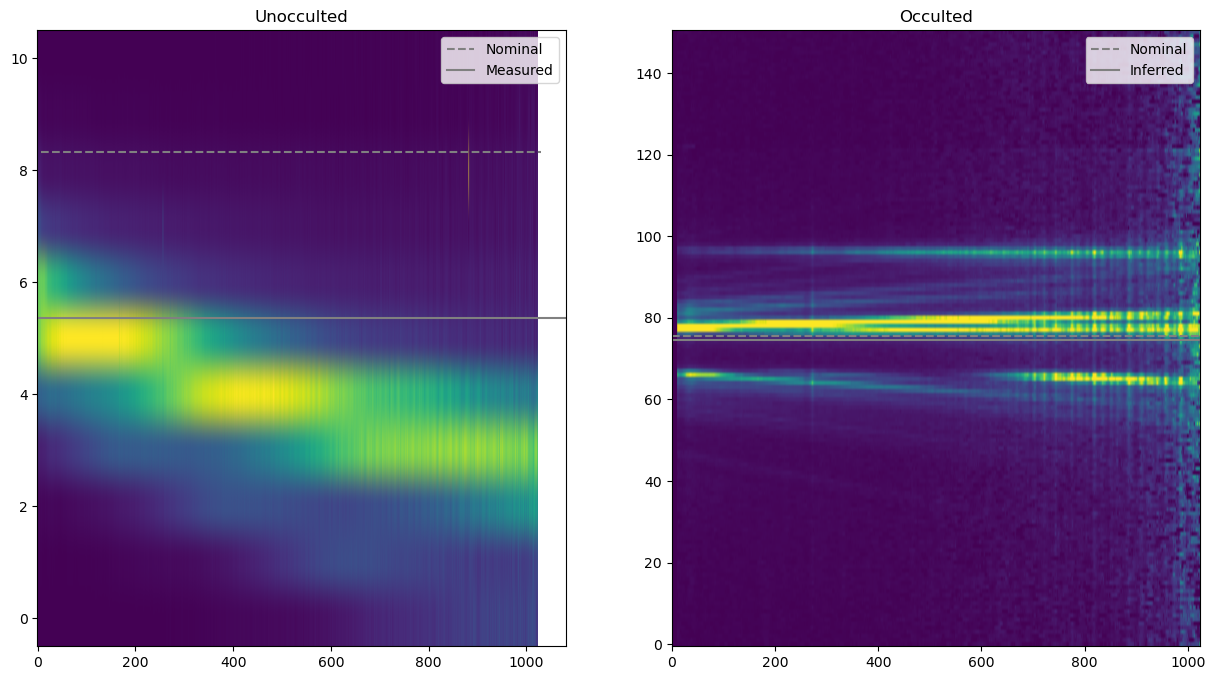

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
# fig.suptitle(hdr['TARGNAME'] + '\n' + hdr['ROOTNAME'] + '\n' + f"POSTARG2: {hdr['POSTARG2']}")
ax = axes[0]
ax.set_title("Unocculted")
ax.imshow(
    obs.unocc_trace.data, 
    **ctmisc.img_vrange(obs.unocc_trace.data),
    origin='lower'
)
nominal_col, nominal_row = obs.unocc_wcs.world_to_pixel_values(
    obs.wlsol, 
    units.Quantity(0, unit='deg')
)

ax.plot(
    nominal_col,
    nominal_row - obs.unocc_trace.origin_original[1],
    c='gray', ls='--', label='Nominal'
)
ax.axhline(
    obs.unocc_row - obs.unocc_trace.origin_original[1],
    c='gray', ls='-', label='Measured'
)
ax.legend()
ax.set_aspect("auto")

ax = axes[1]
ax.set_title("Occulted")
ax.imshow(
    obs.occ_stamp.data, **ctmisc.img_vrange(obs.occ_stamp.data), origin='lower'
)
nominal_col, nominal_row = obs.occ_wcs.world_to_pixel_values(
    obs.wlsol.min(), 
    units.Quantity(0, unit='deg')
)
ax.axhline(nominal_row - obs.occ_stamp.origin_original[1], c='gray', ls='--', label='Nominal')
ax.axhline(obs.occ_stamp_center, c='gray', ls='-', label='Inferred')
ax.legend()
ax.set_aspect("auto")

The WCS doesn't follow the curvature of the trace, but, eh

In [11]:
from coronspec_tools import sdi_tools

## SDI class

Let's examine row 71 in the stamp, the approximate position of the contaminant. We will look at the signal in row 85 of the scaled stamp.

In [12]:
sdi = sdi_tools.SDI(obs, psf_halfwidth=8)

In [13]:
target_row_ind = 96
scaled_row_ind = 110

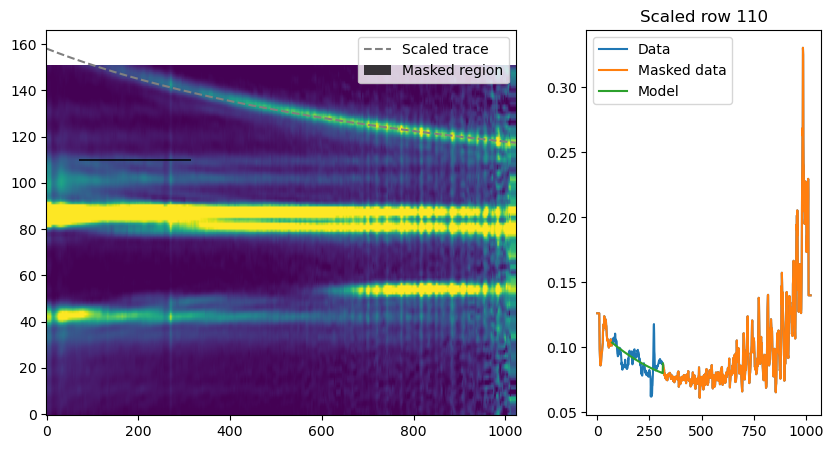

In [15]:
target_row = sdi.obs.occ_stamp.data[target_row_ind]
sdi.compute_scaled_stamp(sdi.ref_wl_ind, obs.occ_stamp.data, obs.occ_stamp_center, fill_end_columns=True, scale_factor=2)
x, y = np.arange(obs.wlsol.size), sdi_tools.compute_scaled_psf_trace(
    target_row_ind, 
    sdi.obs.occ_stamp_center,
    sdi.scale_factors
)
scaled_row = sdi.scaled_stamp[scaled_row_ind]


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), width_ratios=(2, 1))
ax = axes[0]
ax.imshow(
    sdi.scaled_stamp, 
    aspect='auto', origin='lower', **ctmisc.img_vrange(sdi.scaled_stamp, 0.05, 0.95)
)
ax.plot(x, y, c='gray', ls='--', label='Scaled trace')
lb, ub = sdi._compute_row_mask(
    target_row_ind, scaled_row_ind, sdi.psf_halfwidth
)
ax.add_patch(mpl.patches.Rectangle((lb, scaled_row_ind-0.5), (ub-lb), 1, facecolor='k', alpha=0.75, label='Masked region'))
ax.legend()

ax = axes[1]
ax.set_title(f"Scaled row {scaled_row_ind}")
mask = np.zeros_like(scaled_row, dtype=bool)
mask[np.floor(lb).astype(int):np.ceil(ub).astype(int)+1] = True
masked_row = np.ma.masked_array(scaled_row, mask=mask)

ax.plot(scaled_row, label='Data')
ax.plot(masked_row, label='Masked data')

model_row = sdi.model_scaled_row(
    target_row_ind, scaled_row_ind, sdi.psf_halfwidth
)
ax.plot(np.arange(model_row.size)[masked_row.mask], model_row[masked_row.mask], label='Model')
ax.legend()

## SDI schematic

In [105]:
def line(origin, degrees, x):
    slope = np.arctan(np.deg2rad(degrees))
    x0, y0 = origin
    y = slope * (x-x0) + y0
    return y

line((0, 0), 45, np.linspace(1, 2, 11))

array([0.66577375, 0.73235113, 0.7989285 , 0.86550588, 0.93208325,
       0.99866063, 1.065238  , 1.13181538, 1.19839275, 1.26497013,
       1.3315475 ])

Text(0.5, 0, 'Wavelength [A]')

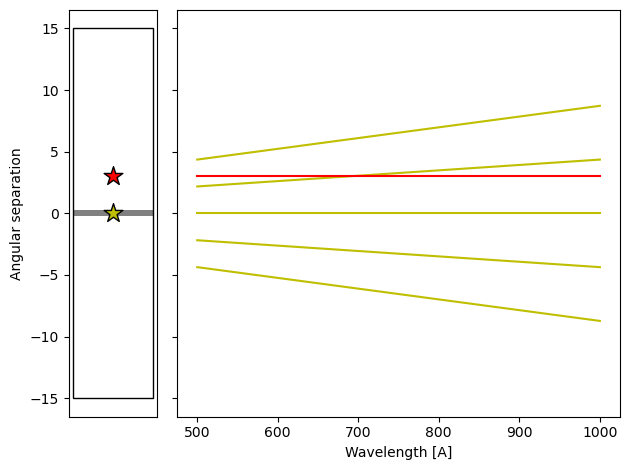

In [107]:
fig, axes = plt.subplots(nrows=1, ncols=2, width_ratios=(1, 5), sharey=True, layout='tight')
primary = (0, 0)
secondary = (0, 3)

ax = axes[0]
bar_height = 0.5
slit_width = 5
slit_height = 30
bar = mpl.patches.Rectangle((-slit_width/2, -bar_height/2), slit_width, bar_height, zorder=-1, fc='gray')
slit = mpl.patches.Rectangle((-slit_width/2, -slit_height/2), slit_width, slit_height, zorder=-1, fill=False, lw=1, ec='k')
ax.add_patch(bar)
ax.add_patch(slit)

ax.scatter(*primary, marker='*', s=200, c='y', ec='k')
ax.scatter(*secondary, marker='*', s=200, c='r', ec='k')

ax.xaxis.set_visible(False)

ax.set_ylabel("Angular separation")

ax = axes[1]
x = np.linspace(500, 1000, 100)
degrees = np.linspace(-0.5, 0.5, 5)
for deg in degrees:
    ax.plot(x, line(origin, deg, x), c='y')
ax.plot(x, line(secondary, 0, x), c='r')

ax.set_xlabel("Wavelength [A]")

In [56]:
# sdi_tools.compute_scaled_psf_trace(star[1], 0, 1/scale_factors)

array([5.5       , 2.89473684, 1.96428571, 1.48648649, 1.19565217,
       1.        , 0.859375  , 0.75342466, 0.67073171, 0.6043956 ,
       0.55      ])

In [144]:
np.logspace(-1e3, 0.25, 10)

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 9.38041867e-223,
       1.29154967e-111, 1.77827941e+000])

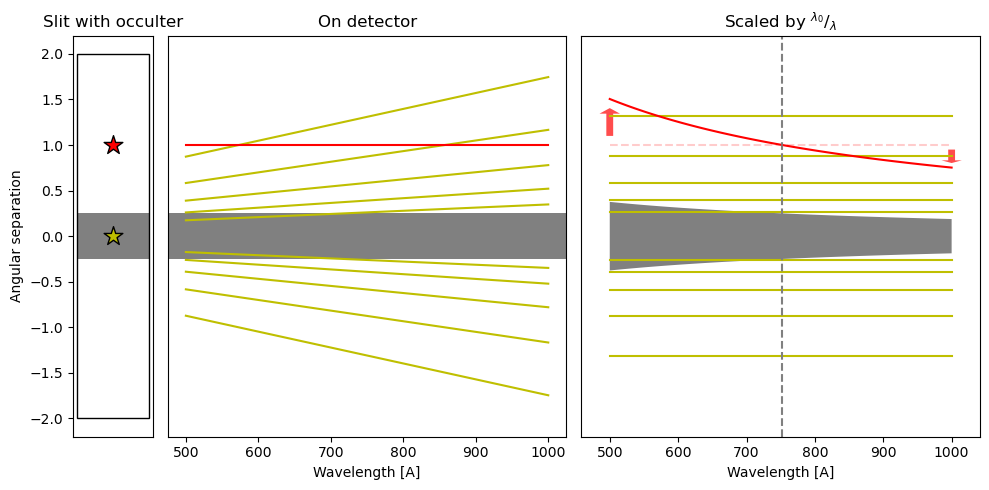

In [217]:
fig, axes = plt.subplots(nrows=1, ncols=3, width_ratios=(1, 5, 5), sharey=True, layout='tight', figsize=(10, 5))

ax.set_title("Detector array")
primary = (0, 0)
secondary = (0, 1)

ax = axes[0]
ax.set_title("Slit with occulter")
bar_height = 0.5
slit_width = 5
slit_height = 4
bar = mpl.patches.Rectangle((-slit_width/2, -bar_height/2), slit_width, bar_height, zorder=-1, fc='gray')
slit = mpl.patches.Rectangle((-slit_width/2, -slit_height/2), slit_width, slit_height, zorder=-1, fill=False, lw=1, ec='k')
ax.add_patch(bar)
ax.add_patch(slit)

ax.scatter(*primary, marker='*', s=200, c='y', ec='k')
ax.scatter(*secondary, marker='*', s=200, c='r', ec='k')

ax.xaxis.set_visible(False)

ax.set_ylabel("Angular separation")

ax = axes[1]
ax.set_title("On detector")
x = np.linspace(500, 1000, 100)
# degrees = np.linspace(-0.25, 0.25, 5)
degrees = np.logspace(-1.7, -1, 5)
degrees = np.concatenate([-degrees, degrees])
for deg in degrees:
    ax.plot(x, line(origin, deg, x), c='y')
ax.plot(x, line(secondary, 0, x), c='r')

ax.axhspan(-0.25, 0.25, fc='gray', zorder=-1)
ax.set_xlabel("Wavelength [A]")

ax.yaxis.set_visible(False)


ax = axes[2]
ax.set_title(r"Scaled by $^{\lambda_{0}}/_{\lambda}$")
ref_wl = x[int(x.size/2)]
scale_factors = ref_wl/x
for deg in degrees:
    ax.plot(x, line(origin, deg, x) * scale_factors, c='y')
scaled_secondary = sdi_tools.compute_scaled_psf_trace(secondary[1], 0, scale_factors)
ax.plot(x, scaled_secondary, c='r')
ax.axvline(ref_wl, ls='--', c='gray')
ax.plot(x, line(secondary, 0, x), c='r',ls='--', alpha=0.2)

arrow_props = dict(width=50, fc='r', alpha=0.7)
uparrow = mpl.patches.Arrow(x.min(), secondary[1]+0.1, 0, (scaled_secondary[0]-secondary[1])-0.2, **arrow_props)
dnarrow = mpl.patches.Arrow(x.max(), secondary[1]-0.05, 0, (scaled_secondary[-1]-secondary[1])+0.1, **arrow_props)
ax.add_patch(uparrow)
ax.add_patch(dnarrow)

top_occulted = np.zeros_like(x)+bar_height/2
ax.fill_between(x, -top_occulted * scale_factors, top_occulted * scale_factors, fc='gray')

ax.set_xlabel("Wavelength [A]")
ax.yaxis.set_visible(False)

In [177]:
mpl.patches.

Init signature: mpl.patches.Arrow(x, y, dx, dy, *, width=1.0, **kwargs)
Docstring:      An arrow patch.
Init docstring:
Draws an arrow from (*x*, *y*) to (*x* + *dx*, *y* + *dy*).
The width of the arrow is scaled by *width*.

Parameters
----------
x : float
    x coordinate of the arrow tail.
y : float
    y coordinate of the arrow tail.
dx : float
    Arrow length in the x direction.
dy : float
    Arrow length in the y direction.
width : float, default: 1
    Scale factor for the width of the arrow. With a default value of 1,
    the tail width is 0.2 and head width is 0.6.
**kwargs
    Keyword arguments control the `Patch` properties:

    Properties:
    agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
    alpha: unknown
    animated: bool
    antialiased or aa: bool or None
    capstyle: `.CapStyle` or {'butt', 'projecting', 'round'}
    clip_box: `~matplotlib.